# Results Processing Notebook

This notebook processes the black box sample results returned each week.
It reads input/output text files from `data/results/`, converts them to `.npy` files,
and saves them into the appropriate function data folders.

**Workflow:**
1. Prompt for the week number to process
2. Read the text files containing inputs and outputs for all 8 functions
3. Combine with initial data to create updated `.npy` files
4. Display the data in tabular form
5. Show convergence graphs for each function

### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Base paths (relative to this notebook's location in functions/results/)
DATA_BASE = '../../data'
RESULTS_DIR = os.path.join(DATA_BASE, 'results')

# Function names and their input dimensions
FUNCTIONS = ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8']

print('Libraries loaded successfully.')
print(f'Results directory: {os.path.abspath(RESULTS_DIR)}')

Libraries loaded successfully.
Results directory: /Users/brucediesel/Development/capstone-sdd/data/results


### Step 2: Prompt for Week Number

In [2]:
# Prompt for the week number to process
week_number = int(input('Enter the week number to process: '))
print(f'\nProcessing results for Week {week_number}')

# Construct file paths
inputs_file = os.path.join(RESULTS_DIR, f'inputs - week {week_number}.txt')
outputs_file = os.path.join(RESULTS_DIR, f'outputs - week {week_number}.txt')

# Verify files exist
assert os.path.exists(inputs_file), f'Input file not found: {inputs_file}'
assert os.path.exists(outputs_file), f'Output file not found: {outputs_file}'
print(f'Input file:  {inputs_file}')
print(f'Output file: {outputs_file}')


Processing results for Week 10
Input file:  ../../data/results/inputs - week 10.txt
Output file: ../../data/results/outputs - week 10.txt


### Step 3: Parse the Text Files

Each line in the text files represents one weekly submission.
Each line contains 8 arrays (one per function).
We parse these and separate the data per function.

In [3]:
def group_records(text):
    """
    Split raw text into logical records using bracket-depth grouping.
    Each record starts with '[' and ends when bracket count returns to zero.
    This handles arrays that wrap across multiple physical lines (e.g. f8's 8D arrays).
    """
    records = []
    current = ''
    depth = 0
    
    for char in text:
        if char == '[':
            depth += 1
            current += char
        elif char == ']':
            depth -= 1
            current += char
            if depth == 0:
                records.append(current.strip())
                current = ''
        elif depth > 0:
            current += char
        # Characters outside brackets (newlines between records) are ignored
    
    return records


def parse_inputs_file(filepath):
    """
    Parse the inputs text file.
    Each record contains a list of 8 numpy arrays, one per function.
    Handles multi-line wrapping (e.g. f8's 8D arrays span 2 physical lines).
    Returns a dict: {func_name: np.ndarray of shape (num_submissions, input_dim)}
    """
    with open(filepath, 'r') as f:
        text = f.read()
    
    records = group_records(text)
    func_inputs = {fn: [] for fn in FUNCTIONS}
    
    for rec_num, record in enumerate(records, 1):
        # Replace 'array(' with 'np.array(' so eval works with numpy
        record_eval = record.replace('array(', 'np.array(')
        try:
            arrays = eval(record_eval)
        except Exception as e:
            raise ValueError(
                f'Failed to parse input record {rec_num}: {e}\n'
                f'Record content: {record[:200]}...'
            )
        
        if len(arrays) != len(FUNCTIONS):
            raise ValueError(
                f'Input record {rec_num} has {len(arrays)} arrays, expected {len(FUNCTIONS)}'
            )
        
        for i, fn in enumerate(FUNCTIONS):
            func_inputs[fn].append(arrays[i])
    
    # Convert lists to numpy arrays
    for fn in FUNCTIONS:
        func_inputs[fn] = np.array(func_inputs[fn])
    
    return func_inputs


def parse_outputs_file(filepath):
    """
    Parse the outputs text file.
    Each record contains a list of 8 float values, one per function.
    Uses bracket-depth grouping for robustness.
    Returns a dict: {func_name: np.ndarray of shape (num_submissions,)}
    """
    with open(filepath, 'r') as f:
        text = f.read()
    
    records = group_records(text)
    func_outputs = {fn: [] for fn in FUNCTIONS}
    
    for rec_num, record in enumerate(records, 1):
        try:
            values = eval(record)
        except Exception as e:
            raise ValueError(
                f'Failed to parse output record {rec_num}: {e}\n'
                f'Record content: {record[:200]}...'
            )
        
        if len(values) != len(FUNCTIONS):
            raise ValueError(
                f'Output record {rec_num} has {len(values)} values, expected {len(FUNCTIONS)}'
            )
        
        for i, fn in enumerate(FUNCTIONS):
            func_outputs[fn].append(float(values[i]))
    
    # Convert to numpy arrays
    for fn in FUNCTIONS:
        func_outputs[fn] = np.array(func_outputs[fn])
    
    return func_outputs


# Parse both files
new_inputs = parse_inputs_file(inputs_file)
new_outputs = parse_outputs_file(outputs_file)

# --- Out-of-range input validation (T023) ---
# Warn on values outside valid range [0.0, 1.0]
for fn in FUNCTIONS:
    arr = new_inputs[fn]
    for row_idx in range(arr.shape[0]):
        for col_idx in range(arr.shape[1]):
            val = arr[row_idx, col_idx]
            if val < 0.0 or val > 1.0:
                print(f'⚠️  Out-of-range value in {fn}, submission {row_idx+1}, '
                      f'dim {col_idx+1}: {val:.6f}')

# Display summary of parsed data
print(f'\nParsed submission data:')
print(f'{"Function":<10} {"Submissions":<15} {"Input Dims":<12}')
print('-' * 37)
for fn in FUNCTIONS:
    print(f'{fn:<10} {new_inputs[fn].shape[0]:<15} {new_inputs[fn].shape[1]:<12}')


Parsed submission data:
Function   Submissions     Input Dims  
-------------------------------------
f1         10              2           
f2         10              2           
f3         10              3           
f4         10              4           
f5         10              4           
f6         10              5           
f7         10              6           
f8         10              8           


### Step 4: Combine with Initial Data and Save `.npy` Files

For each function, we concatenate the initial data with all the weekly submissions
to create the updated dataset, then save as `.npy` files.

In [4]:
updated_inputs = {}
updated_outputs = {}

# Always build the combined data (needed by display and convergence cells)
for fn in FUNCTIONS:
    initial_inp = np.load(os.path.join(DATA_BASE, fn, 'initial_inputs.npy'))
    initial_out = np.load(os.path.join(DATA_BASE, fn, 'initial_outputs.npy'))
    updated_inputs[fn] = np.vstack([initial_inp, new_inputs[fn]])
    updated_outputs[fn] = np.concatenate([initial_out, new_outputs[fn]])

# --- Overwrite guard (FR-014) ---
existing_files = []
for fn in FUNCTIONS:
    inp_path = os.path.join(DATA_BASE, fn, f'updated_inputs - Week {week_number}.npy')
    out_path = os.path.join(DATA_BASE, fn, f'updated_outputs - Week {week_number}.npy')
    if os.path.exists(inp_path):
        existing_files.append(inp_path)
    if os.path.exists(out_path):
        existing_files.append(out_path)

proceed = True
if existing_files:
    print(f'⚠️  WARNING: {len(existing_files)} file(s) for Week {week_number} already exist:')
    for ef in existing_files[:6]:
        print(f'   {ef}')
    if len(existing_files) > 6:
        print(f'   ... and {len(existing_files) - 6} more')
    confirm = input('Overwrite existing files? (yes/no): ').strip().lower()
    proceed = confirm in ('yes', 'y')

if not proceed:
    print('Save skipped — existing files were NOT overwritten.')
else:
    print(f'Saving updated .npy files for Week {week_number}:')
    print(f'{"Function":<10} {"Initial":<10} {"+ New":<10} {"= Total":<10} {"Saved To"}')
    print('-' * 70)

    for fn in FUNCTIONS:
        inp_path = os.path.join(DATA_BASE, fn, f'updated_inputs - Week {week_number}.npy')
        out_path = os.path.join(DATA_BASE, fn, f'updated_outputs - Week {week_number}.npy')
        np.save(inp_path, updated_inputs[fn])
        np.save(out_path, updated_outputs[fn])

        initial_inp = np.load(os.path.join(DATA_BASE, fn, 'initial_inputs.npy'))
        n_initial = len(initial_inp)
        n_new = len(new_inputs[fn])
        n_total = len(updated_inputs[fn])
        print(f'{fn:<10} {n_initial:<10} {n_new:<10} {n_total:<10} data/{fn}/')

    print(f'\nAll .npy files saved successfully for Week {week_number}.')

Saving updated .npy files for Week 10:
Function   Initial    + New      = Total    Saved To
----------------------------------------------------------------------
f1         10         10         20         data/f1/
f2         10         10         20         data/f2/
f3         15         10         25         data/f3/
f4         30         10         40         data/f4/
f5         20         10         30         data/f5/
f6         20         10         30         data/f6/
f7         30         10         40         data/f7/
f8         40         10         50         data/f8/

All .npy files saved successfully for Week 10.


### Step 5: Display Updated Inputs and Outputs in Tabular Form

Show the complete updated dataset for each function as a table.

In [5]:
for fn in FUNCTIONS:
    inp = updated_inputs[fn]
    out = updated_outputs[fn]
    n_initial = len(np.load(os.path.join(DATA_BASE, fn, 'initial_inputs.npy')))
    
    # Build a DataFrame with input columns and output
    n_dims = inp.shape[1]
    columns = [f'x{i+1}' for i in range(n_dims)] + ['y (output)']
    data = np.column_stack([inp, out])
    df = pd.DataFrame(data, columns=columns)
    
    # Add a source column to indicate initial vs weekly submission
    source = ['Initial'] * n_initial + [f'Week {i+1}' for i in range(len(inp) - n_initial)]
    df.insert(0, 'Source', source)
    
    print(f'\n{"=" * 80}')
    print(f'Function {fn.upper()} — Updated Data (Week {week_number})')
    print(f'{"=" * 80}')
    display(df)
    print()


Function F1 — Updated Data (Week 10)


,Source,x1,x2,y (output)
0,Initial,0.319404,0.762959,1.322677e-79
1,Initial,0.574329,0.879898,1.033078e-46
2,Initial,0.731024,0.733000,7.710875e-16
3,Initial,0.840353,0.264732,3.341771e-124
4,Initial,0.650114,0.681526,-3.606063e-03
5,Initial,0.410437,0.147554,-2.159249e-54
6,Initial,0.312691,0.078723,-2.089093e-91
7,Initial,0.683418,0.861057,2.535001e-40
8,Initial,0.082507,0.403488,3.606771e-81
9,Initial,0.883890,0.582254,6.229856e-48




Function F2 — Updated Data (Week 10)


,Source,x1,x2,y (output)
0,Initial,0.665800,0.123969,0.538996
1,Initial,0.877791,0.778628,0.420586
2,Initial,0.142699,0.349005,-0.065624
3,Initial,0.845275,0.711120,0.293993
4,Initial,0.454647,0.290455,0.214965
5,Initial,0.577713,0.771973,0.023106
6,Initial,0.438166,0.685018,0.244619
7,Initial,0.341750,0.028698,0.038749
8,Initial,0.338648,0.213867,-0.013858
9,Initial,0.702637,0.926564,0.611205




Function F3 — Updated Data (Week 10)


...

,Source,x1,x2,x3,x4,x5,y (output)
0,Initial,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,Initial,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,Initial,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,Initial,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,Initial,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,Initial,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,Initial,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,Initial,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,Initial,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,Initial,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116




Function F7 — Updated Data (Week 10)


,Source,x1,x2,x3,x4,x5,x6,y (output)
0,Initial,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,Initial,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,Initial,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,Initial,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,Initial,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,Initial,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,Initial,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,Initial,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,Initial,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,Initial,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565




Function F8 — Updated Data (Week 10)


,Source,x1,x2,x3,x4,x5,x6,x7,x8,y (output)
0,Initial,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,Initial,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,Initial,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,Initial,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,Initial,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,Initial,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,Initial,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,Initial,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,Initial,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,Initial,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


### Step 6: Convergence Graphs

For each function, plot the convergence of the best observed output value over time.
This shows whether the Bayesian optimisation is finding better solutions each week.

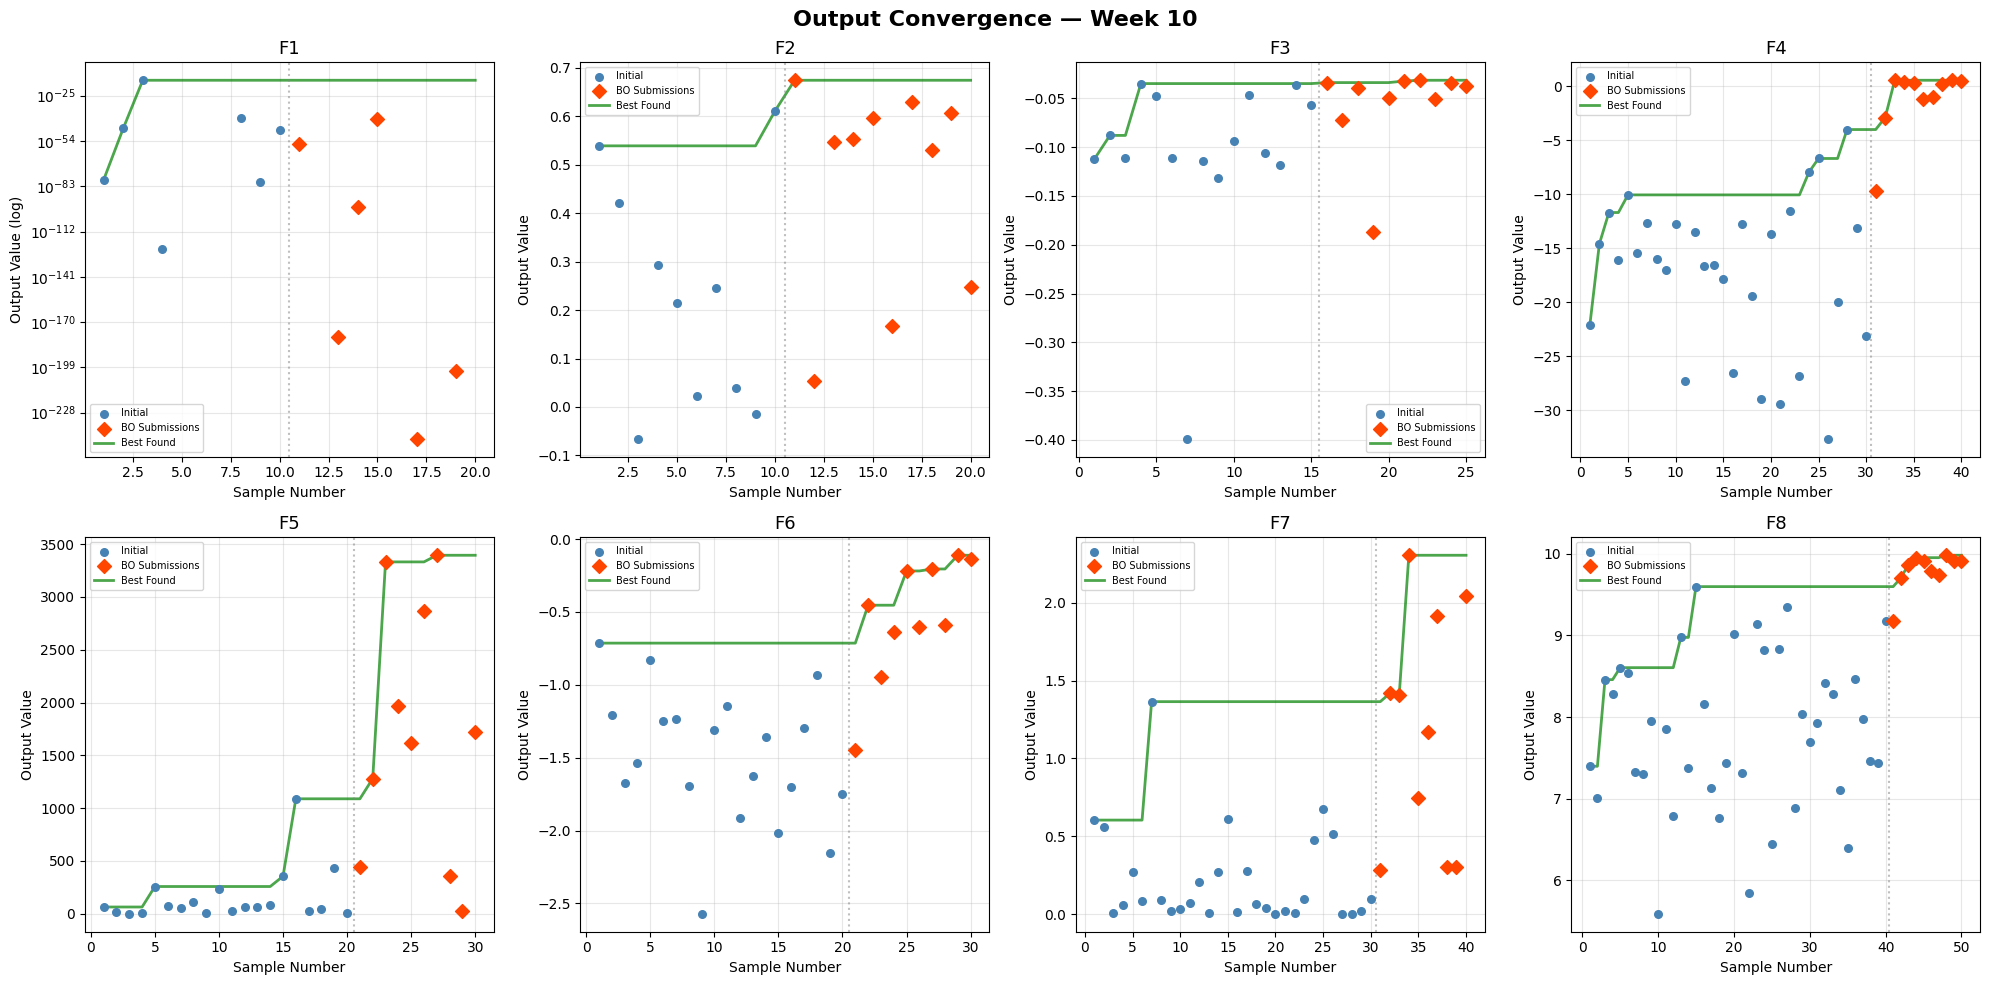

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'Output Convergence — Week {week_number}', fontsize=16, fontweight='bold')

for idx, fn in enumerate(FUNCTIONS):
    ax = axes[idx // 4, idx % 4]
    out = updated_outputs[fn]
    n_initial = len(np.load(os.path.join(DATA_BASE, fn, 'initial_inputs.npy')))

    # F1: clip negative outputs to zero so log scale can be used
    if fn == 'f1':
        out = np.maximum(out, 0)

    # Running maximum — all problems are maximisation tasks
    running_max = np.maximum.accumulate(out)

    # Plot all observed values
    sample_indices = np.arange(1, len(out) + 1)
    ax.scatter(sample_indices[:n_initial], out[:n_initial],
               c='steelblue', label='Initial', zorder=3, s=30)
    ax.scatter(sample_indices[n_initial:], out[n_initial:],
               c='orangered', label='BO Submissions', zorder=3, s=50, marker='D')

    # Plot running best (max only — maximisation)
    ax.plot(sample_indices, running_max, 'g-', alpha=0.7, linewidth=2, label='Best Found')

    # Mark the boundary between initial and BO samples
    ax.axvline(x=n_initial + 0.5, color='gray', linestyle=':', alpha=0.5)

    ax.set_title(f'{fn.upper()}', fontsize=13)
    ax.set_xlabel('Sample Number')
    ax.set_ylabel('Output Value')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

    # F1: use log scale to better see outputs spanning many orders of magnitude
    if fn == 'f1':
        ax.set_yscale('log')
        ax.set_ylabel('Output Value (log)')

plt.tight_layout()
plt.show()

### Step 7: Summary Statistics

A quick summary of the best values found for each function after this week's update.

In [7]:
print(f'Summary — Best Observed Values (Week {week_number})')
print(f'{"Function":<10} {"Min Output":<20} {"Max Output":<20} {"Best Input (at Max)"}')
print('-' * 80)

for fn in FUNCTIONS:
    inp = updated_inputs[fn]
    out = updated_outputs[fn]
    min_idx = np.argmin(out)
    max_idx = np.argmax(out)

    min_val = out[min_idx]
    max_val = out[max_idx]
    best_input = inp[max_idx]

    # Format the best input
    input_str = ', '.join([f'{v:.6f}' for v in best_input])
    print(f'{fn:<10} {min_val:<20.6e} {max_val:<20.6e} [{input_str}]')

Summary — Best Observed Values (Week 10)
Function   Min Output           Max Output           Best Input (at Max)
--------------------------------------------------------------------------------
f1         -3.606063e-03        7.710875e-16         [0.731024, 0.733000]
f2         -6.562362e-02        6.743554e-01         [0.693877, 0.673469]
f3         -3.989255e-01        -3.142738e-02        [0.063229, 0.711381, 0.367390]
f4         -3.262566e+01        5.321755e-01         [0.427629, 0.419856, 0.400742, 0.398136]
f5         1.129398e-01         3.394680e+03         [0.989923, 0.278871, 0.923543, 0.995886]
f6         -2.571170e+00        -1.114895e-01        [0.402330, 0.330813, 0.573610, 0.733655, 0.100000]
f7         2.701465e-03         2.304991e+00         [0.000000, 0.261823, 0.623526, 0.173633, 0.352400, 0.687293]
f8         5.592193e+00         9.982473e+00         [0.107773, 0.160839, 0.142888, 0.158839, 0.835332, 0.507655, 0.196162, 0.999999]
